In [ ]:

import kagglehub
drugreview_path = kagglehub.dataset_download('mohamedabdelwahabali/drugreview')

print('Data source import complete.')


100%|██████████| 199M/199M [00:05<00:00, 38.3MB/s]

Extracting files...


Data source import complete.


In [ ]:

# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [ ]:
import re
import string
import nltk
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
train_df = pd.read_csv(drugreview_path + '/drug_review_train.csv')
val_df = pd.read_csv(drugreview_path + '/drug_review_validation.csv')
test_df = pd.read_csv(drugreview_path + '/drug_review_test.csv')

In [ ]:
train_df.head(15)

,Unnamed: 0,patient_id,drugName,condition,review,rating,date,usefulCount,review_length
0,0,89879,Cyclosporine,keratoconjunctivitis sicca,"""i have used restasis for about a year now and...",2.0,"April 20, 2013",69,147
1,1,143975,Etonogestrel,birth control,"""my experience has been somewhat mixed. i have...",7.0,"August 7, 2016",4,136
2,2,106473,Implanon,birth control,"""this is my second implanon would not recommen...",1.0,"May 11, 2016",6,140
3,3,184526,Hydroxyzine,anxiety,"""i recommend taking as prescribed, and the bot...",10.0,"March 19, 2012",124,104
4,4,91587,Dalfampridine,multiple sclerosis,"""i have been on ampyra for 5 days and have bee...",9.0,"August 1, 2010",101,74
5,5,218554,Tri-Sprintec,birth control,"""used for birth control and period issues- ver...",2.0,"January 7, 2017",4,57
6,6,207442,Suprep Bowel Prep Kit,bowel preparation,"""my prep instructions were one 6oz bottle the ...",8.0,"December 5, 2016",18,86
7,7,63753,Epiduo,acne,"""love it. i had the worst breakouts, so i got ...",9.0,"October 19, 2011",20,63
8,8,140845,Escitalopram,depression,"""i felt a positive difference within the first...",9.0,"April 21, 2016",13,49
9,9,182520,Mirena,birth control,"""i have been on mirena for over a year now and...",1.0,"June 15, 2009",45,37


In [ ]:

# Select only the 'review' and 'rating' columns
train_df = train_df[['review', 'rating']]
val_df = val_df[['review', 'rating']]
test_df = test_df[['review', 'rating']]

In [ ]:
train_df.head(25)

,review,rating
0,"""i have used restasis for about a year now and...",2.0
1,"""my experience has been somewhat mixed. i have...",7.0
2,"""this is my second implanon would not recommen...",1.0
3,"""i recommend taking as prescribed, and the bot...",10.0
4,"""i have been on ampyra for 5 days and have bee...",9.0
5,"""used for birth control and period issues- ver...",2.0
6,"""my prep instructions were one 6oz bottle the ...",8.0
7,"""love it. i had the worst breakouts, so i got ...",9.0
8,"""i felt a positive difference within the first...",9.0
9,"""i have been on mirena for over a year now and...",1.0


In [ ]:

print(train_df.info())
print(val_df.info())
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110811 entries, 0 to 110810
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   review  110811 non-null  object 
 1   rating  110811 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27703 entries, 0 to 27702
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   review  27703 non-null  object 
 1   rating  27703 non-null  float64
dtypes: float64(1), object(1)
memory usage: 433.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46108 entries, 0 to 46107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   review  46108 non-null  object 
 1   rating  46108 non-null  float64
dtypes: float64(1), object(1)
memory usage: 720.6+ KB
None


In [ ]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

review    0
rating    0
dtype: int64
review    0
rating    0
dtype: int64
review    0
rating    0
dtype: int64


In [ ]:
def sentiments_label(rating):
    if rating >= 7:
        return 'positive'
    elif rating >= 4:
        return 'neutral'
    else:
        return 'negative'

# Apply sentiment labeling (corrected)
train_df.loc[:, 'sentiment'] = train_df['rating'].apply(sentiments_label)
val_df.loc[:, 'sentiment'] = val_df['rating'].apply(sentiments_label)
test_df.loc[:, 'sentiment'] = test_df['rating'].apply(sentiments_label)

In [ ]:
print(train_df[['rating', 'sentiment']].head())

   rating sentiment
0     2.0  negative
1     7.0  positive
2     1.0  negative
3    10.0  positive
4     9.0  positive


In [ ]:
train_df = train_df.drop('rating', axis=1)
val_df = val_df.drop('rating', axis=1)
test_df = test_df.drop('rating', axis=1)

In [ ]:
train_df

train_df.head(10)

,review,sentiment
0,"""i have used restasis for about a year now and...",negative
1,"""my experience has been somewhat mixed. i have...",positive
2,"""this is my second implanon would not recommen...",negative
3,"""i recommend taking as prescribed, and the bot...",positive
4,"""i have been on ampyra for 5 days and have bee...",positive
5,"""used for birth control and period issues- ver...",negative
6,"""my prep instructions were one 6oz bottle the ...",positive
7,"""love it. i had the worst breakouts, so i got ...",positive
8,"""i felt a positive difference within the first...",positive
9,"""i have been on mirena for over a year now and...",negative


In [ ]:
train_df.describe()

,review,sentiment
count,110811,110811
unique,84138,3
top,"""hi everyone, \r\r\ni am a 22 yr old female an...",positive
freq,4,73638


In [ ]:

train_df['sentiment'].value_counts()

,count
sentiment,
positive,73638
negative,23602
neutral,13571


In [ ]:

print(f"New dataset size: {train_df.shape}")

New dataset size: (110811, 2)


In [ ]:

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

In [ ]:


def normalize_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:


def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [ ]:

# def lemmatize_text(text):
#     lemmatizer = WordNetLemmatizer()
#     words = word_tokenize(text)
#     lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
#     return " ".join(lemmatized_words)

def stemming(text):
    ps = PorterStemmer()
    words = text.split()
    return " ".join([ps.stem(word) for word in words])


In [ ]:

def clean_text(text):
    text = normalize_text(text)
    text = remove_punctuation(text)
    text = remove_stopwords(text)
    text = stemming(text)
    return text

In [ ]:

train_df['clean_review'] = train_df['review'].apply(clean_text)
val_df['clean_review'] = val_df['review'].apply(clean_text)
test_df['clean_review'] = test_df['review'].apply(clean_text)

print(train_df[['review', 'clean_review']].head())  # View sample cleaned data

                                              review  \
0  "i have used restasis for about a year now and...   
1  "my experience has been somewhat mixed. i have...   
2  "this is my second implanon would not recommen...   
3  "i recommend taking as prescribed, and the bot...   
4  "i have been on ampyra for 5 days and have bee...   

                                        clean_review  
0  use restasi year seen almost progress life red...  
1  experi somewhat mix use implanon nearli 14 mon...  
2  second implanon would recommend first one okay...  
3  recommend take prescrib bottl usual say take x...  
4  ampyra 5 day happi new pill first 2 day good s...  


In [ ]:
# Label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_df['sentiment_encoded'] = label_encoder.fit_transform(train_df['sentiment'])
val_df['sentiment_encoded'] = label_encoder.transform(val_df['sentiment'])
test_df['sentiment_encoded'] = label_encoder.transform(test_df['sentiment'])
print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [ ]:

# Tokenization and padding
max_words = 10000
max_len = 150
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df['clean_review'])
X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_review']), maxlen=max_len)
X_val = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_review']), maxlen=max_len)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_review']), maxlen=max_len)
y_train = train_df['sentiment_encoded'].values
y_val = val_df['sentiment_encoded'].values
y_test = test_df['sentiment_encoded'].values

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (110811, 150)
X_val shape: (27703, 150)
X_test shape: (46108, 150)


In [ ]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=30, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 59s 14ms/step - accuracy: 0.7194 - loss: 0.7159 - val_accuracy: 0.7535 - val_loss: 0.6316
Epoch 2/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.7727 - loss: 0.5789 - val_accuracy: 0.7596 - val_loss: 0.6122
Epoch 3/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - accuracy: 0.7989 - loss: 0.5178 - val_accuracy: 0.6843 - val_loss: 0.7584
Epoch 4/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - accuracy: 0.7782 - loss: 0.5605 - val_accuracy: 0.7684 - val_loss: 0.6057
Epoch 5/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.8348 - loss: 0.4400 - val_accuracy: 0.7657 - val_loss: 0.6297
Epoch 6/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - accuracy: 0.8366 - loss: 0.4370 - val_accuracy: 0.7628 - val_loss: 0.6422
Epoch 7/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - accuracy: 0.8392 - loss: 0.4249 - val_accuracy: 0.7463 - val_loss: 0.6584
Epoch 8/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 80s 14ms/step - accuracy: 0.8492 -

In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64),
    Dense(3, activation='softmax')
])
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=30, verbose=1)

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3694/3694 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.7400 - loss: 0.6652 - val_accuracy: 0.7706 - val_loss: 0.5885
Epoch 2/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.8007 - loss: 0.5040 - val_accuracy: 0.7816 - val_loss: 0.5543
Epoch 3/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.8366 - loss: 0.4206 - val_accuracy: 0.7959 - val_loss: 0.5398
Epoch 4/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8727 - loss: 0.3351 - val_accuracy: 0.8006 - val_loss: 0.5447
Epoch 5/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.9037 - loss: 0.2646 - val_accuracy: 0.8194 - val_loss: 0.5703
Epoch 6/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.9299 - loss: 0.1984 - val_accuracy: 0.8185 - val_loss: 0.6175
Epoch 7/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 77s 10ms/step - accuracy: 0.9474 - loss: 0.1527 - val_accuracy: 0.8294 - val_loss: 0.6333
Epoch 8/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.9613 - loss: 0.11

In [ ]:

from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dense(3, activation='softmax')
])
model_bilstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_bilstm = model_bilstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=30, verbose=1)

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3694/3694 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - accuracy: 0.7386 - loss: 0.6677 - val_accuracy: 0.7745 - val_loss: 0.5729
Epoch 2/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 16ms/step - accuracy: 0.8012 - loss: 0.5053 - val_accuracy: 0.7877 - val_loss: 0.5459
Epoch 3/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 85s 17ms/step - accuracy: 0.8380 - loss: 0.4167 - val_accuracy: 0.7959 - val_loss: 0.5345
Epoch 4/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - accuracy: 0.8750 - loss: 0.3331 - val_accuracy: 0.8096 - val_loss: 0.5298
Epoch 5/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9071 - loss: 0.2553 - val_accuracy: 0.8121 - val_loss: 0.5624
Epoch 6/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - accuracy: 0.9299 - loss: 0.1961 - val_accuracy: 0.8244 - val_loss: 0.5943
Epoch 7/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 16ms/step - accuracy: 0.9496 - loss: 0.1462 - val_accuracy: 0.8298 - val_loss: 0.6584
Epoch 8/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 86s 17ms/step - accuracy: 0.9630 - loss: 0.11

In [ ]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

model_attention = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, return_sequences=True),
    AttentionLayer(),
    Dense(3, activation='softmax')
])
model_attention.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_attention = model_attention.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=30, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.7310 - loss: 0.6882 - val_accuracy: 0.7720 - val_loss: 0.5767
Epoch 2/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.8037 - loss: 0.4993 - val_accuracy: 0.7849 - val_loss: 0.5438
Epoch 3/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - accuracy: 0.8301 - loss: 0.4286 - val_accuracy: 0.7955 - val_loss: 0.5407
Epoch 4/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - accuracy: 0.8643 - loss: 0.3506 - val_accuracy: 0.8045 - val_loss: 0.5503
Epoch 5/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.8954 - loss: 0.2796 - val_accuracy: 0.8139 - val_loss: 0.5691
Epoch 6/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9224 - loss: 0.2121 - val_accuracy: 0.8211 - val_loss: 0.5922
Epoch 7/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9404 - loss: 0.1660 - val_accuracy: 0.8228 - val_loss: 0.6746
Epoch 8/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - accuracy: 0.9574 -

In [ ]:
model_bilstm_attention = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    AttentionLayer(),
    Dense(3, activation='softmax')
])
model_bilstm_attention.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_bilstm_attention = model_bilstm_attention.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=30, verbose=1)

Epoch 1/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 81s 19ms/step - accuracy: 0.7336 - loss: 0.6861 - val_accuracy: 0.7739 - val_loss: 0.5714
Epoch 2/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 81s 19ms/step - accuracy: 0.8008 - loss: 0.5049 - val_accuracy: 0.7850 - val_loss: 0.5436
Epoch 3/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 74s 17ms/step - accuracy: 0.8351 - loss: 0.4253 - val_accuracy: 0.7975 - val_loss: 0.5303
Epoch 4/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.8691 - loss: 0.3449 - val_accuracy: 0.8029 - val_loss: 0.5454
Epoch 5/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.8983 - loss: 0.2748 - val_accuracy: 0.8155 - val_loss: 0.5542
Epoch 6/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9239 - loss: 0.2089 - val_accuracy: 0.8268 - val_loss: 0.5880
Epoch 7/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.9419 - loss: 0.1639 - val_accuracy: 0.8249 - val_loss: 0.6771
Epoch 8/15
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 67s 18ms/step - accuracy: 0.9586 -

In [ ]:


val_loss_rnn, val_acc_rnn = model_rnn.evaluate(X_val, y_val, verbose=0)
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f"RNN - Val Acc: {val_acc_rnn:.4f}, Test Acc: {test_acc_rnn:.4f}")

val_loss_lstm, val_acc_lstm = model_lstm.evaluate(X_val, y_val, verbose=0)
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"LSTM - Val Acc: {val_acc_lstm:.4f}, Test Acc: {test_acc_lstm:.4f}")

val_loss_bilstm, val_acc_bilstm = model_bilstm.evaluate(X_val, y_val, verbose=0)
test_loss_bilstm, test_acc_bilstm = model_bilstm.evaluate(X_test, y_test, verbose=0)
print(f"BiLSTM - Val Acc: {val_acc_bilstm:.4f}, Test Acc: {test_acc_bilstm:.4f}")

val_loss_attention, val_acc_attention = model_attention.evaluate(X_val, y_val, verbose=0)
test_loss_attention, test_acc_attention = model_attention.evaluate(X_test, y_test, verbose=0)
print(f"Attention - Val Acc: {val_acc_attention:.4f}, Test Acc: {test_acc_attention:.4f}")

val_loss_bilstm_att, val_acc_bilstm_att = model_bilstm_attention.evaluate(X_val, y_val, verbose=0)
test_loss_bilstm_att, test_acc_bilstm_att = model_bilstm_attention.evaluate(X_test, y_test, verbose=0)
print(f"BiLSTM+Attention - Val Acc: {val_acc_bilstm_att:.4f}, Test Acc: {test_acc_bilstm_att:.4f}")



RNN - Val Acc: 0.7920, Test Acc: 0.7880
LSTM - Val Acc: 0.8417, Test Acc: 0.8364
BiLSTM - Val Acc: 0.8459, Test Acc: 0.8450
Attention - Val Acc: 0.8442, Test Acc: 0.8444
BiLSTM+Attention - Val Acc: 0.8441, Test Acc: 0.8433


1441/1441 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step


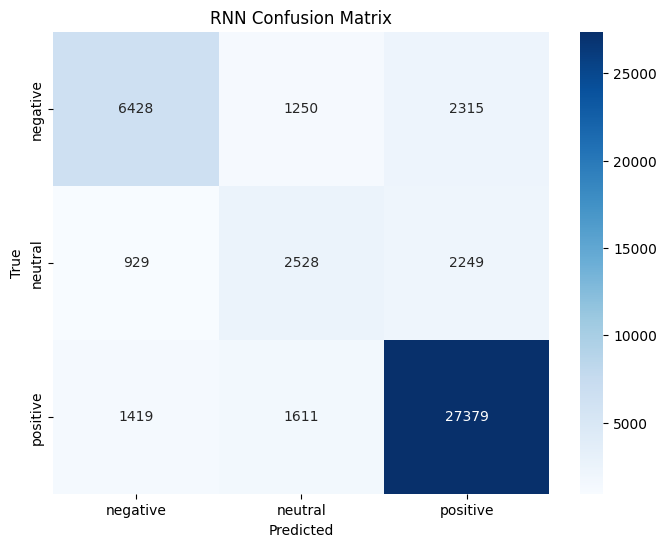

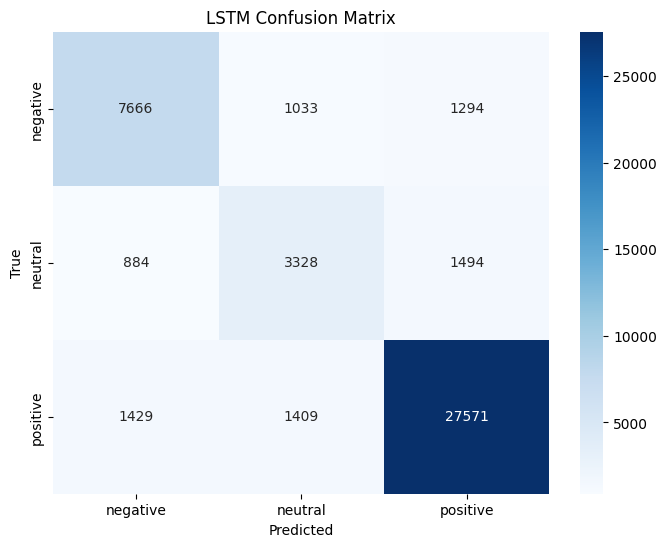

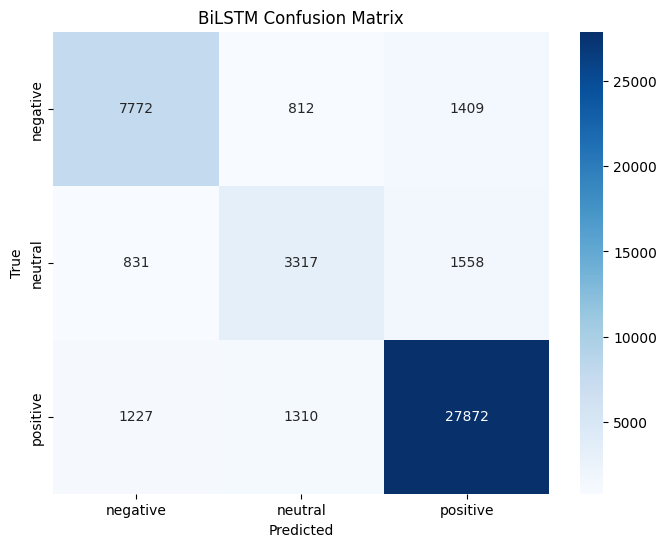

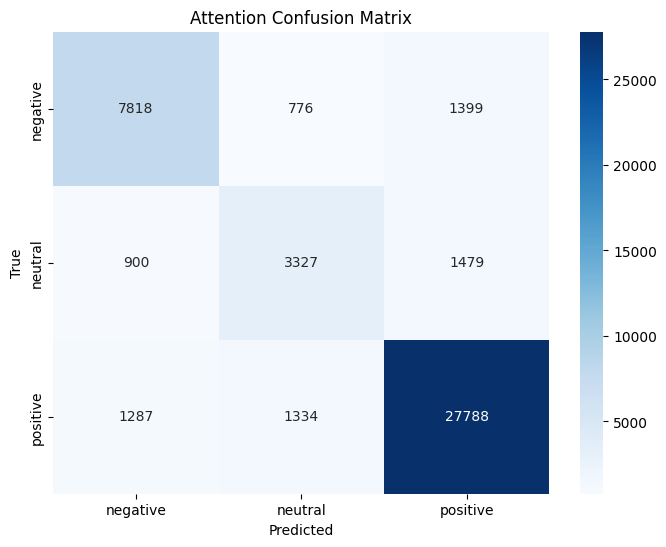

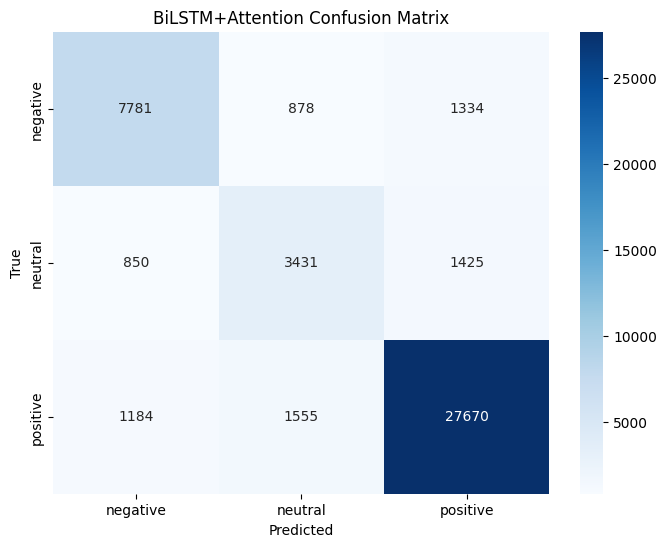

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

y_pred_rnn = np.argmax(model_rnn.predict(X_test), axis=1)
y_pred_lstm = np.argmax(model_lstm.predict(X_test), axis=1)
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test), axis=1)
y_pred_attention = np.argmax(model_attention.predict(X_test), axis=1)
y_pred_bilstm_att = np.argmax(model_bilstm_attention.predict(X_test), axis=1)

plot_confusion_matrix(y_test, y_pred_rnn, 'RNN Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_lstm, 'LSTM Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_bilstm, 'BiLSTM Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_attention, 'Attention Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_bilstm_att, 'BiLSTM+Attention Confusion Matrix')


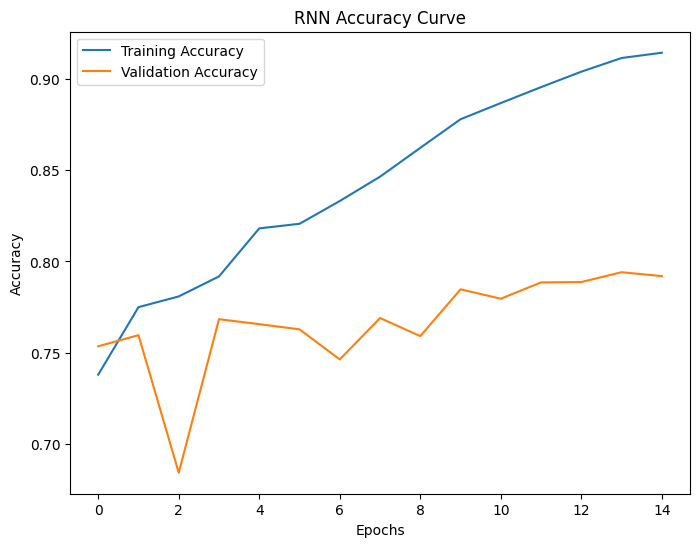

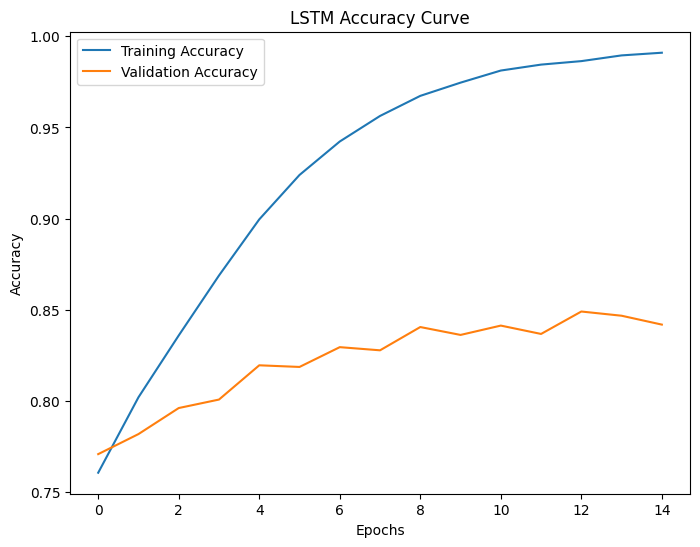

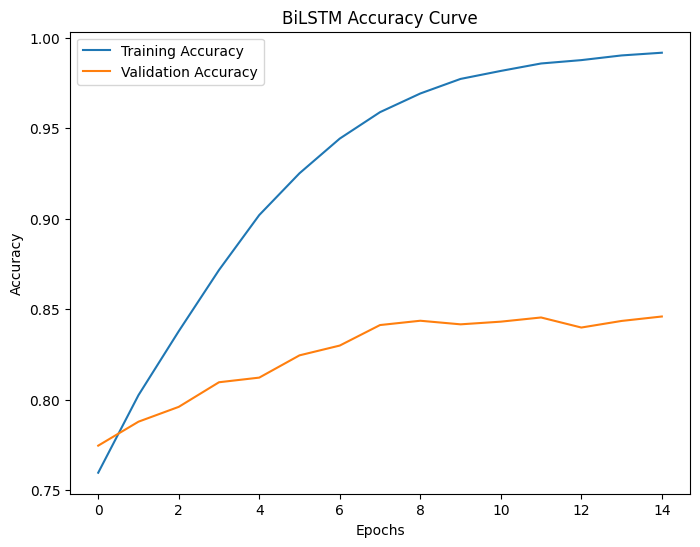

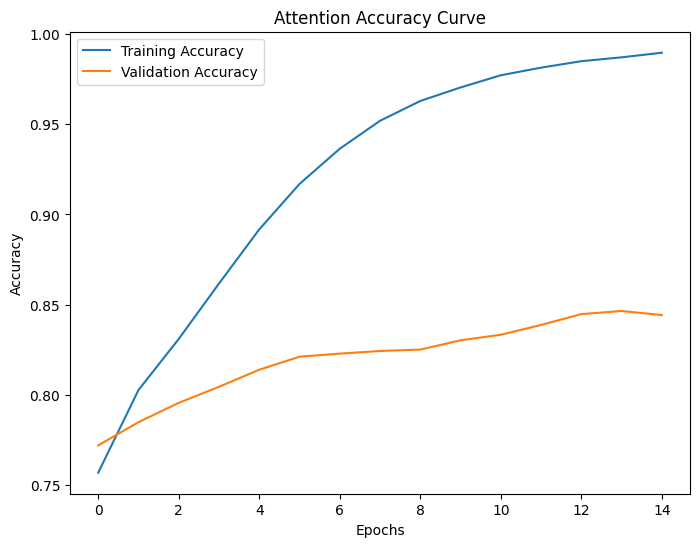

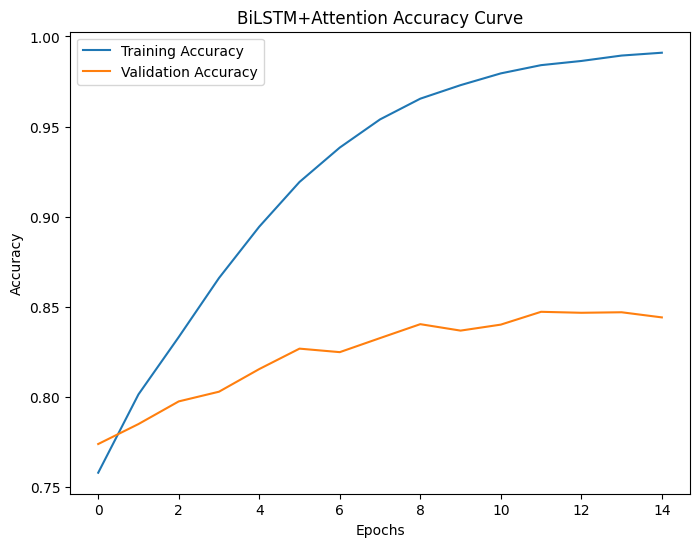

In [ ]:
def plot_accuracy_curve(history, title):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
     # Set y-axis range from 0 to 1 for accuracy
    plt.show()

# Plot accuracy curves for each model
plot_accuracy_curve(history_rnn, 'RNN Accuracy Curve')
plot_accuracy_curve(history_lstm, 'LSTM Accuracy Curve')
plot_accuracy_curve(history_bilstm, 'BiLSTM Accuracy Curve')
plot_accuracy_curve(history_attention, 'Attention Accuracy Curve')
plot_accuracy_curve(history_bilstm_attention, 'BiLSTM+Attention Accuracy Curve')


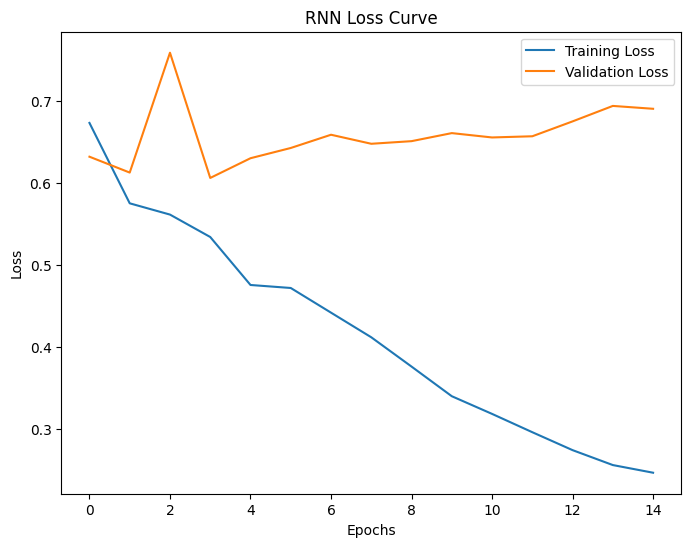

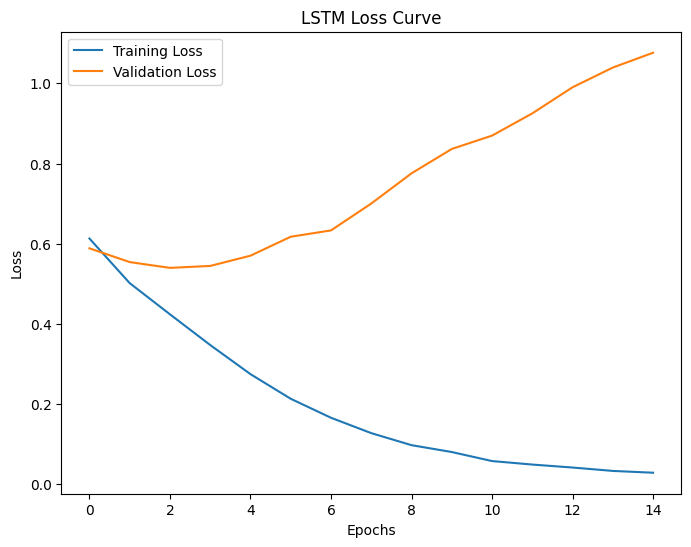

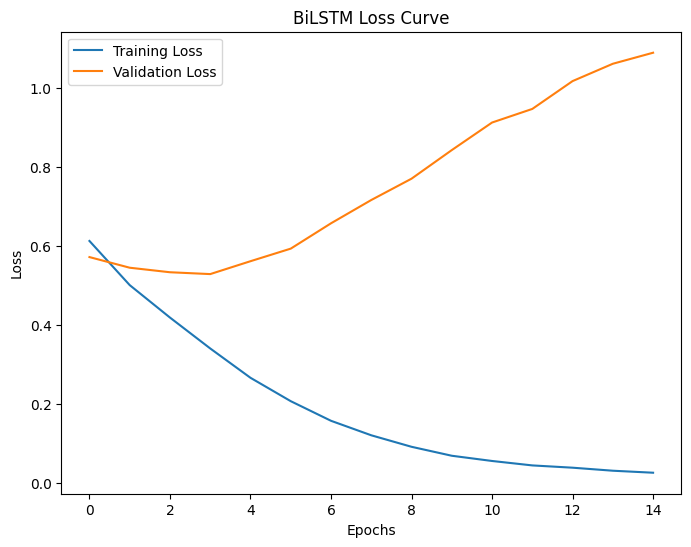

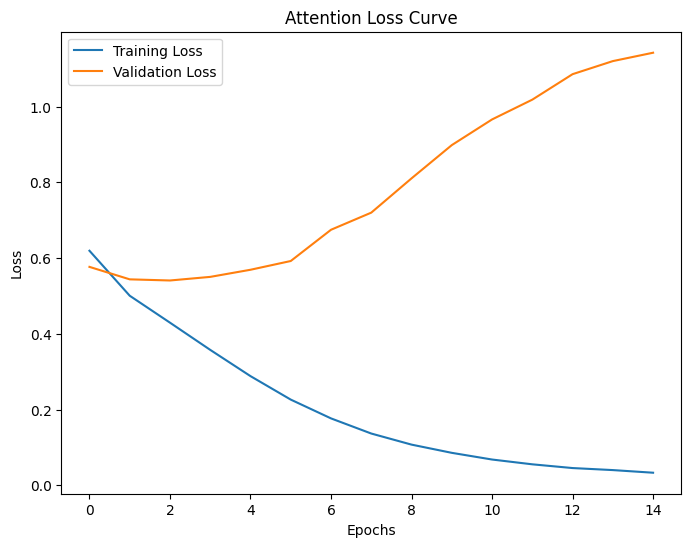

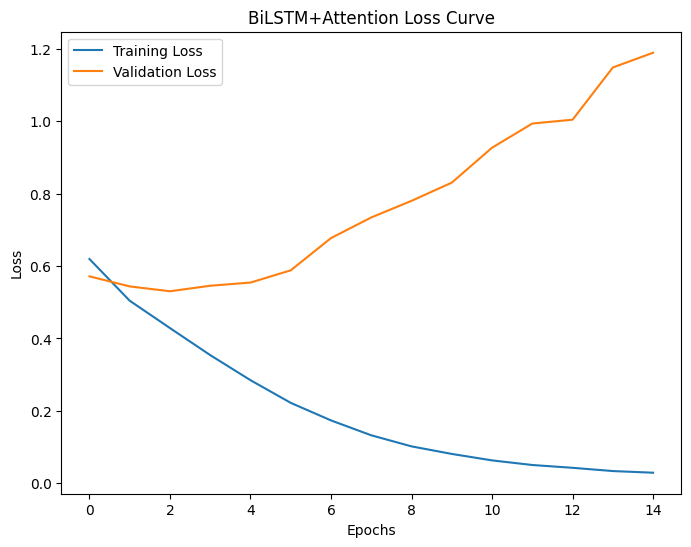

In [ ]:

def plot_loss_curve(history, title):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss_curve(history_rnn, 'RNN Loss Curve')
plot_loss_curve(history_lstm, 'LSTM Loss Curve')
plot_loss_curve(history_bilstm, 'BiLSTM Loss Curve')
plot_loss_curve(history_attention, 'Attention Loss Curve')
plot_loss_curve(history_bilstm_attention, 'BiLSTM+Attention Loss Curve')


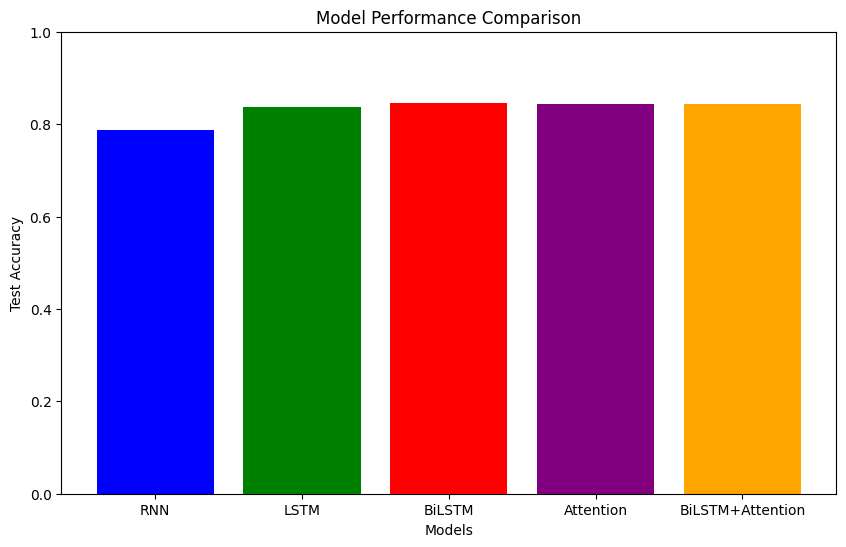

In [ ]:
models = ['RNN', 'LSTM', 'BiLSTM', 'Attention', 'BiLSTM+Attention']
test_accuracies = [test_acc_rnn, test_acc_lstm, test_acc_bilstm, test_acc_attention, test_acc_bilstm_att]

plt.figure(figsize=(10, 6))
plt.bar(models, test_accuracies, color=['blue', 'green', 'red', 'purple', 'orange', 'cyan'])
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.show()

In [ ]:
nltk.download('punkt_tab')